## Imports Section:

In [1]:
import numpy as np
import pandas as pd
import random
import scipy
from scipy import stats
import datetime as dt
import dask.dataframe as dd

In [2]:
import librosa
import warnings

In [3]:
import glob
import matplotlib.pyplot as plt
from matplotlib import colors
import soundfile as sf
import matplotlib.patches as patches
from pathlib import Path

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm

In [5]:
import sys

# append the path of the
# parent directory
sys.path.append('..')
sys.path.append('../src/')
sys.path.append('../src/models/bat_call_detector/batdetect2/')

import src.batdt2_pipeline as batdetect2_pipeline
import src.file_dealer as file_dealer

In [6]:
from sklearn.cluster import KMeans
LABEL_FOR_GROUPS = {
                    0: 'LF', 
                    1: 'HF'
                    }

## Function Definitions (most important functions are in `src/`)
### Below are the functions used for plotting and visualization

In [7]:
def convert_bd2df_ravenpro(df: pd.DataFrame):
    """
    Converts a dataframe to the format used by RavenPro
    """

    ravenpro_df = df.copy()

    ravenpro_df.rename(columns={
        "start_time": "Begin Time (s)",
        "end_time": "End Time (s)",
        "low_freq": "Low Freq (Hz)",
        "high_freq": "High Freq (Hz)",
        "event": "Annotation",
        "freq_group":"Manually-Verified Phonic Group",
        'snr_nist_quick_dB':'SNR NIST Quick (dB)',
        'delta_time_s':'Delta Time (s)'
    }, inplace=True)

    ravenpro_df["Selection"] = np.arange(0, df.shape[0]).astype('int') + 1
    ravenpro_df["View"] = "Waveform 1"
    ravenpro_df["Channel"] = "1"

    return ravenpro_df

In [8]:
FREQ_COLORS = {'LF':'cyan', 'HF':'orange'}

In [9]:
file_sites = {'20220730_053000':'Carp',
 '20220826_070000':'Central',
 '20220727_083000':'Foliage',
 '20220829_090000':'Foliage'}
bd2_dets_save_dir = Path(f'20250124__group_threshold_sweep_results')
raventxt_human_files_dir = f'{Path.home()}/Documents/Research/mila_files/mila-human-wav-txt'
kaleidoscope_dets_save_dir = Path.home() / f'Documents'
extension = ".txt"
sep = "\t"

SITE_NAMES = {'Carp':'Carp Pond', 'Foliage':'Foliage', 'Central':'Central Pond'}
TP_CLASSIFICATION_THRESHOLD = 0.008
OVERLAP_TIME_THRESHOLD = 0.012

file_keys = list(file_sites.keys())
file_keys

['20220730_053000', '20220826_070000', '20220727_083000', '20220829_090000']

## Following the confusion matrix structure shown below

![image](example_confusion_matrix.png)

In [10]:
all_files_batdetct2_df_true_positives = pd.DataFrame()
all_files_batdetct2_df = pd.DataFrame()
file_key = '20220826_070000'
wav_filename = file_key
site = file_sites[file_key]
plot_file = Path(f'{raventxt_human_files_dir}/{wav_filename}.WAV')
raventxt_human_filename = f'{wav_filename}_manually_verified_by_AK_with_groups'

snr_included_ravenpro_human_txt = pd.read_csv(f'{raventxt_human_files_dir}/{raventxt_human_filename}_ravenpro_SNR_aditya_SNR_and_peakfreqtime.txt', sep=sep)
bd2_human_df_file = snr_included_ravenpro_human_txt.copy()
bd2_human_df_file = bd2_human_df_file.drop(columns=['Selection', 'View', 'Channel'])
bd2_human_df_file.rename(columns={'Begin Time (s)':'start_time',
                            'End Time (s)':'end_time',
                            'Low Freq (Hz)':'low_freq',
                            'High Freq (Hz)':'high_freq',
                            'Delta Time (s)':'delta_time_s',
                            'Manually-Verified Phonic Group':'freq_group',
                            'SNR NIST Quick (dB)':'snr_nist_quick_dB'}, inplace=True)
bd2_human_df_file.sort_values('start_time', inplace=True)
lf_bd2_human_df_file = bd2_human_df_file[bd2_human_df_file['freq_group']=='LF'].reset_index(drop=True).copy()
hf_bd2_human_df_file = bd2_human_df_file[bd2_human_df_file['freq_group']=='HF'].reset_index(drop=True).copy()
len(bd2_human_df_file), len(lf_bd2_human_df_file), len(hf_bd2_human_df_file)

(4406, 1138, 3268)

In [11]:
def return_true_positives_using_human_df(human_df, machine_df):
    dist_matrix = np.zeros((len(machine_df), len(human_df)))
    association_matrix = np.zeros((len(machine_df), len(human_df)), dtype='bool')
    collect_human = pd.DataFrame()
    collect_bd2 = pd.DataFrame()
    for index in range(len(machine_df)):
        batdetect2_row = machine_df.iloc[index]
        dist_to_all_calls = ((human_df['peak_frequency_time'] - batdetect2_row['peak_frequency_time_SPECTROGRAM']).values)
        dist_matrix[index,:] = dist_to_all_calls
    
        dist_to_all_calls[np.abs(dist_to_all_calls)>=TP_CLASSIFICATION_THRESHOLD] = 1
        dist_to_all_calls[np.abs(dist_to_all_calls)<TP_CLASSIFICATION_THRESHOLD] = 0
        if np.abs(dist_to_all_calls-1).sum() > 1:
            collect_human = pd.concat([collect_human, human_df[dist_to_all_calls<0.5]])
            collect_bd2 = pd.concat([collect_bd2, pd.DataFrame(batdetect2_row).T])

        association_matrix[index,:] = ~dist_to_all_calls.astype('bool')

    human_bd2_true_positives = human_df.loc[np.logical_or.reduce(association_matrix, axis=0)]
    machine_false_negatives = human_df.loc[~(np.logical_or.reduce(association_matrix, axis=0))]
    machine_true_positives = machine_df.loc[np.logical_or.reduce(association_matrix, axis=1)]
    machine_false_positives = machine_df.loc[~(np.logical_or.reduce(association_matrix, axis=1))]

    separated_performance_dfs = dict()
    separated_performance_dfs['machine_true_positives'] = machine_true_positives
    separated_performance_dfs['machine_false_positives'] = machine_false_positives
    separated_performance_dfs['machine_false_negatives'] = machine_false_negatives
    separated_performance_dfs['human_true_positives'] = human_bd2_true_positives

    return association_matrix, separated_performance_dfs

In [12]:
args = dict()
args['chunk_size'] = 2
args['detection_threshold'] = 0.00
ones = int(args['detection_threshold'])
decimals = int(int(100*(args['detection_threshold'])) % 100)
threshold_tag = f"threshold{ones}p{decimals:02}"
save_loc_reduced_overlaps = Path(f"bd2__{threshold_tag}_chunksize{int(args['chunk_size'])}_{wav_filename}_REDUCED_OVERLAPS.csv")
filepath_reduced_overlaps = bd2_dets_save_dir / save_loc_reduced_overlaps
bd2_file_all_dets = pd.read_csv(filepath_reduced_overlaps, sep=',', index_col=0)
bd2_file_all_dets.rename(columns={'KMEANS_CLASSES':'freq_group'}, inplace=True)
lf_bd2_file_all_dets = bd2_file_all_dets[bd2_file_all_dets['freq_group']=='LF'].reset_index(drop=True).copy()
hf_bd2_file_all_dets = bd2_file_all_dets[bd2_file_all_dets['freq_group']=='HF'].reset_index(drop=True).copy()

In [13]:
args = dict()
args['chunk_size'] = 2
args['detection_threshold'] = 0.00

ones = int(args['detection_threshold'])
decimals = int(int(100*(args['detection_threshold'])) % 100)
threshold_tag = f"threshold{ones}p{decimals:02}"
save_loc = Path(f"bd2__{threshold_tag}_chunksize{int(args['chunk_size'])}_{wav_filename}.csv")

filepath = bd2_dets_save_dir / save_loc
batdetect2_df = pd.read_csv(filepath, sep=',', index_col=0)
batdetect2_df.rename(columns={'KMEANS_CLASSES':'freq_group'}, inplace=True)
selected_batdetect2_df = batdetect2_df[(batdetect2_df['start_time']>=346)&(batdetect2_df['end_time']<=347)].reset_index(drop=True)
selected_batdetect2_df

,freq_group,peak_frequency_time_SPECTROGRAM,peak_frequency_SPECTROGRAM,peak_frequency_WELCH,SNR,start_time,end_time,low_freq,high_freq,class,class_prob,det_prob,individual,event,sampling_rate,input_file
0,LF,346.013467,21000.0,22080.0,0.851943,346.0015,346.0157,20312,25345,Nyctalus noctula,0.012,0.032,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...
1,HF,346.022433,77250.0,71040.0,0.434200,346.0015,346.0324,68437,80515,Rhinolophus ferrumequinum,0.042,0.043,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...
2,LF,346.022800,21750.0,22080.0,0.711696,346.0085,346.0262,19453,23032,Nyctalus noctula,0.016,0.031,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...
3,HF,346.026667,70500.0,72960.0,0.313846,346.0115,346.0540,68437,82432,Rhinolophus ferrumequinum,0.024,0.024,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...
4,LF,346.022367,27750.0,27840.0,0.895862,346.0215,346.0293,28046,38156,Eptesicus serotinus,0.010,0.030,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,HF,346.909467,41250.0,41280.0,7.311484,346.9055,346.9137,38359,46565,Pipistrellus nathusii,0.265,0.449,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...
68,LF,346.929767,21750.0,22080.0,0.755673,346.9235,346.9434,19453,23362,Nyctalus noctula,0.014,0.025,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...
69,HF,346.927033,37500.0,38400.0,-2.840253,346.9255,346.9338,36640,42835,Pipistrellus nathusii,0.012,0.025,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...
70,HF,346.951533,60000.0,59520.0,0.680258,346.9485,346.9553,56406,63586,Pipistrellus pygmaeus,0.025,0.026,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...


In [14]:
dist_mat_comp_batdetect2_df = batdetect2_df.copy()
association_mat = np.ones((len(dist_mat_comp_batdetect2_df), len(dist_mat_comp_batdetect2_df)), dtype='bool')
for index in range(len(dist_mat_comp_batdetect2_df)):
    row = dist_mat_comp_batdetect2_df.iloc[index]
    dist_to_all_calls = ((dist_mat_comp_batdetect2_df['peak_frequency_time_SPECTROGRAM'] - row['peak_frequency_time_SPECTROGRAM']).values)

    considered_inds = np.where(np.abs(dist_to_all_calls)<=OVERLAP_TIME_THRESHOLD)[0]
    considered_dets = batdetect2_df.iloc[considered_inds]

    det_choices = np.zeros(len(considered_inds))
    likely_call_ind = considered_dets['det_prob'].argmax()

    det_choices[likely_call_ind] = 1
    association_mat[considered_inds, index] = det_choices

reduced_overlaps_batdetect2_df = batdetect2_df[np.logical_and.reduce(association_mat, axis=1)]

In [15]:
reduced_overlaps_batdetect2_df[(reduced_overlaps_batdetect2_df['start_time']>=346.7)&(reduced_overlaps_batdetect2_df['end_time']<=347)]

,freq_group,peak_frequency_time_SPECTROGRAM,peak_frequency_SPECTROGRAM,peak_frequency_WELCH,SNR,start_time,end_time,low_freq,high_freq,class,class_prob,det_prob,individual,event,sampling_rate,input_file
18753,HF,346.735633,72750.0,72000.0,1.040470,346.7165,346.7562,68437,81953,Rhinolophus ferrumequinum,0.025,0.025,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...
18754,HF,346.720800,41250.0,41280.0,3.711329,346.7175,346.7252,38359,48411,Pipistrellus nathusii,0.248,0.347,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...
18756,HF,346.754900,53250.0,52800.0,3.257206,346.7515,346.7591,49531,61454,Pipistrellus pygmaeus,0.144,0.209,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...
18759,HF,346.813667,40500.0,41280.0,1.250709,346.8105,346.8195,39218,44213,Pipistrellus nathusii,0.222,0.256,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...
18764,LF,346.855400,33000.0,31680.0,2.603337,346.8545,346.8611,30625,43153,Myotis daubentonii,0.018,0.038,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...
18769,HF,346.877700,45750.0,45120.0,0.632079,346.8745,346.8823,45234,50154,Pipistrellus pipistrellus,0.024,0.033,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...
18770,HF,346.909467,41250.0,41280.0,7.311484,346.9055,346.9137,38359,46565,Pipistrellus nathusii,0.265,0.449,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...
18771,LF,346.929767,21750.0,22080.0,0.755673,346.9235,346.9434,19453,23362,Nyctalus noctula,0.014,0.025,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...
18774,LF,346.953000,27000.0,27840.0,0.468544,346.9525,346.9595,27187,39427,Eptesicus serotinus,0.007,0.027,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...


In [16]:
# bd2_file_all_dets = pd.read_csv(filepath_reduced_overlaps, sep=',', index_col=0)
bd2_file_all_dets = reduced_overlaps_batdetect2_df.copy()
bd2_file_all_dets.rename(columns={'KMEANS_CLASSES':'freq_group'}, inplace=True)
lf_bd2_file_all_dets = bd2_file_all_dets[bd2_file_all_dets['freq_group']=='LF'].reset_index(drop=True).copy()
hf_bd2_file_all_dets = bd2_file_all_dets[bd2_file_all_dets['freq_group']=='HF'].reset_index(drop=True).copy()

In [17]:
lf_association_matrix, lf_separated_performance_dfs = return_true_positives_using_human_df(lf_bd2_human_df_file, lf_bd2_file_all_dets)
hf_association_matrix, hf_separated_performance_dfs = return_true_positives_using_human_df(hf_bd2_human_df_file, hf_bd2_file_all_dets)

In [18]:
np.logical_or.reduce(lf_association_matrix, axis=1).shape, np.logical_or.reduce(hf_association_matrix, axis=1).shape, 

((29783,), (22936,))

In [19]:
lf_association_matrix[np.logical_or.reduce(lf_association_matrix, axis=1),:].shape, hf_association_matrix[np.logical_or.reduce(hf_association_matrix, axis=1),:].shape

((1044, 1138), (3209, 3268))

## Below matrix is rectangular because at this stage, there are some batdetect2 detections that overlap more than once with human annotations

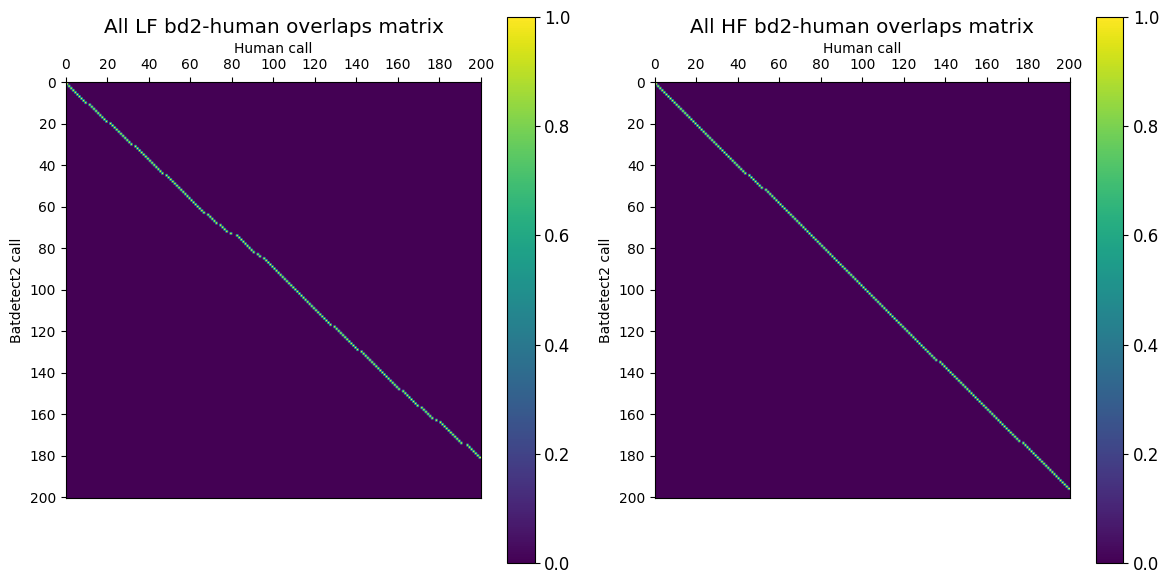

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,6))
plt.rcParams.update({'font.size':12})

samples=200
ax1.set_title('All LF bd2-human overlaps matrix')
im = ax1.imshow((lf_association_matrix[np.logical_or.reduce(lf_association_matrix, axis=1),:])[:samples,:samples])
ax1.set_xlabel('Human call')
ax1.xaxis.set_label_position('top')
ax1.set_ylabel('Batdetect2 call')
ax1.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)
fig.colorbar(im, orientation='vertical')
ax1.set_xticks(np.linspace(0, samples, 11)-0.75,
              np.linspace(0, samples, 11).astype(int))
ax1.set_yticks(np.linspace(0, samples, 11)-0.925,
              np.linspace(0, samples, 11).astype(int))



samples=200
ax2.set_title('All HF bd2-human overlaps matrix')
im = ax2.imshow((hf_association_matrix[np.logical_or.reduce(hf_association_matrix, axis=1),:])[:samples,:samples])
ax2.set_xlabel('Human call')
ax2.xaxis.set_label_position('top')
ax2.set_ylabel('Batdetect2 call')
ax2.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)
fig.colorbar(im, orientation='vertical')
ax2.set_xticks(np.linspace(0, samples, 11)-0.75,
              np.linspace(0, samples, 11).astype(int))
ax2.set_yticks(np.linspace(0, samples, 11)-0.925,
              np.linspace(0, samples, 11).astype(int))

plt.tight_layout()
plt.show()

In [21]:
hf_human_true_positives = lf_separated_performance_dfs['human_true_positives']
lf_bd2_false_negatives = lf_separated_performance_dfs['machine_false_negatives']
lf_bd2_true_positives = lf_separated_performance_dfs['machine_true_positives']
lf_bd2_false_positives = lf_separated_performance_dfs['machine_false_positives']
print(len(hf_human_true_positives), len(lf_bd2_false_negatives), len(lf_bd2_true_positives), len(lf_bd2_false_positives))

1044 94 1044 28739


In [22]:
hf_human_true_positives = hf_separated_performance_dfs['human_true_positives']
hf_bd2_false_negatives = hf_separated_performance_dfs['machine_false_negatives']
hf_bd2_true_positives = hf_separated_performance_dfs['machine_true_positives']
hf_bd2_false_positives = hf_separated_performance_dfs['machine_false_positives']
print(len(hf_human_true_positives), len(hf_bd2_false_negatives), len(hf_bd2_true_positives), len(hf_bd2_false_positives))

3212 56 3209 19727


In [26]:
num_trues_each_row = lf_association_matrix.sum(axis=1)
bd2_dets_with_overlap_human_dets = lf_bd2_file_all_dets.iloc[np.where(num_trues_each_row>1)[0]]
print(bd2_dets_with_overlap_human_dets.index.values)
lf_bd2_human_df_file[lf_association_matrix[3209,:]]

[]


,start_time,end_time,low_freq,high_freq,delta_time_s,snr_nist_quick_dB,Annotation,detection_confidence,input_file,freq_group,adityas_method_snr_dB,peak_frequency_time


In [27]:
num_trues_each_col = lf_association_matrix.sum(axis=0)
human_dets_with_overlap_bd2_dets = lf_bd2_human_df_file.iloc[np.where(num_trues_each_col>1)[0]]
print(human_dets_with_overlap_bd2_dets.index.values)
lf_bd2_file_all_dets[lf_association_matrix[:,812]]

[]


,freq_group,peak_frequency_time_SPECTROGRAM,peak_frequency_SPECTROGRAM,peak_frequency_WELCH,SNR,start_time,end_time,low_freq,high_freq,class,class_prob,det_prob,individual,event,sampling_rate,input_file
12106,LF,693.145633,26250.0,25920.0,4.563265,693.1405,693.1592,25468,28614,Nyctalus leisleri,0.314,0.392,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...


In [28]:
plt.figure(figsize=(20, 10))
plt.rcParams.update({'font.size': 24})
for i, sel_ind in enumerate((human_dets_with_overlap_bd2_dets.index).values):
    plt.subplot(2,4,i+1)
    selection_row = lf_bd2_human_df_file.iloc[sel_ind]
    file_name = f'{wav_filename}.WAV'
    file_path = Path(raventxt_human_files_dir) / file_name
    audio_file = sf.SoundFile(file_path)
    fs = audio_file.samplerate

    start = selection_row['start_time']-0.03
    audio_file.seek(int(fs*(start)))
    duration = (selection_row['end_time']-selection_row['start_time'])+0.06
    audio_seg = audio_file.read(int(fs*duration))

    plt.specgram(audio_seg, NFFT=156, Fs=fs, cmap='jet', vmin=-120, vmax=0)

    ax = plt.gca()
    rect = patches.Rectangle(((selection_row['start_time'] - start), selection_row['low_freq']), 
                    (selection_row['end_time'] - selection_row['start_time']), (selection_row['high_freq'] - selection_row['low_freq']), 
                    linewidth=1.5, edgecolor='yellow', facecolor='none', alpha=0.8)
    ax.add_patch(rect)
    ax.axvline(x=selection_row['peak_frequency_time']-start, linestyle='dashed', color='yellow')

    plot_bd2dets = lf_bd2_file_all_dets[(lf_bd2_file_all_dets['start_time']>=start)&(lf_bd2_file_all_dets['end_time']<=(start+duration))]
    for i, row in plot_bd2dets.iterrows():
        rect = patches.Rectangle(((row['start_time'] - start), row['low_freq']), 
                        (row['end_time'] - row['start_time']), (row['high_freq'] - row['low_freq']), 
                        linewidth=1.5, edgecolor=FREQ_COLORS[selection_row['freq_group']], facecolor='none', alpha=0.8)
        ax.add_patch(rect)
        ax.axvline(x=row['peak_frequency_time_SPECTROGRAM']-start, linestyle='dashed', color='cyan', 
                label=f"Δt = {round(1000*(row['peak_frequency_time_SPECTROGRAM'] - selection_row['peak_frequency_time']), 3)}ms")

    plt.yticks(ticks=np.linspace(0, fs/2, 6), labels=np.linspace(0, fs/2000, 6).astype('int'))
    plt.legend(fontsize=18)
    plt.ylabel("Frequency (kHz)")
    plt.xlabel("Time (s)")

plt.tight_layout()
plt.show()

<Figure size 2000x1000 with 0 Axes>

Above the detections within the `TP_CLASSIFICATION_THRESHOLD` are part of the true positives. They are within `TP_CLASSIFICATION_THRESHOLD` of the human annotation but NOT within `OVERLAP_TIME_THRESHOLD` of each other (which is why neither of them were dropped)

In [31]:
num_trues_each_row = hf_association_matrix.sum(axis=1)
bd2_dets_with_overlap_human_dets = hf_bd2_file_all_dets.iloc[np.where(num_trues_each_row>1)[0]]
print(bd2_dets_with_overlap_human_dets.index.values)
hf_bd2_human_df_file[hf_association_matrix[3209,:]]

[ 3209 18087 22083]


,start_time,end_time,low_freq,high_freq,delta_time_s,snr_nist_quick_dB,Annotation,detection_confidence,input_file,freq_group,adityas_method_snr_dB,peak_frequency_time
531,246.849189,246.857813,45295.775,57775.076,0.0086,13.30,v,NaN,NaN,HF,6.877655,246.853898
532,246.858984,246.865694,37521.127,47323.944,0.0067,18.41,v,NaN,NaN,HF,5.973619,246.860941


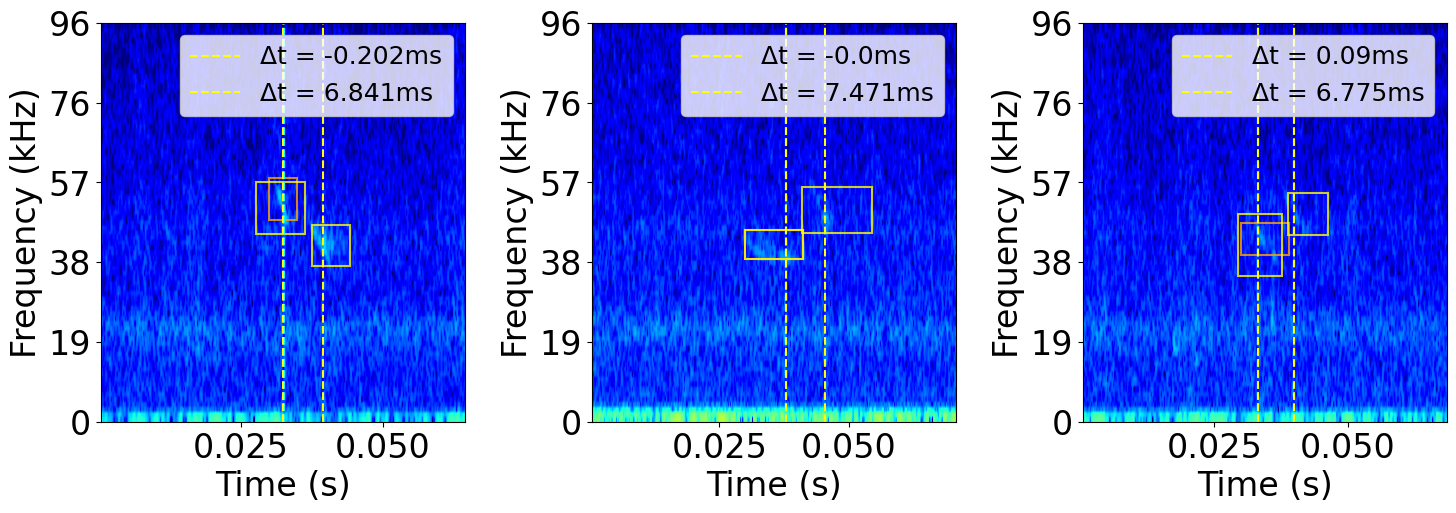

In [32]:
plt.figure(figsize=(20, 10))
plt.rcParams.update({'font.size': 24})
for i, sel_ind in enumerate((bd2_dets_with_overlap_human_dets.index).values):
    plt.subplot(2,4,i+1)
    selection_row = hf_bd2_file_all_dets.iloc[sel_ind]
    input_file = Path(selection_row['input_file'])
    file_name = input_file.name
    file_path = Path(raventxt_human_files_dir) / file_name
    audio_file = sf.SoundFile(file_path)
    fs = audio_file.samplerate

    start = selection_row['start_time']-0.03
    audio_file.seek(int(fs*(start)))
    duration = (selection_row['end_time']-selection_row['start_time'])+0.06
    audio_seg = audio_file.read(int(fs*duration))

    plt.specgram(audio_seg, NFFT=156, Fs=fs, cmap='jet', vmin=-120, vmax=0)

    ax = plt.gca()
    rect = patches.Rectangle(((selection_row['start_time'] - start), selection_row['low_freq']), 
                    (selection_row['end_time'] - selection_row['start_time']), (selection_row['high_freq'] - selection_row['low_freq']), 
                    linewidth=1.5, edgecolor=FREQ_COLORS[selection_row['freq_group']], facecolor='none', alpha=0.8)
    ax.add_patch(rect)
    ax.axvline(x=selection_row['peak_frequency_time_SPECTROGRAM']-start, linestyle='dashed', color='cyan')

    plot_humandets = hf_bd2_human_df_file[(hf_bd2_human_df_file['start_time']>=start)&(hf_bd2_human_df_file['end_time']<=(start+duration))]
    for i, row in plot_humandets.iterrows():
        rect = patches.Rectangle(((row['start_time'] - start), row['low_freq']), 
                        (row['end_time'] - row['start_time']), (row['high_freq'] - row['low_freq']), 
                        linewidth=1.5, edgecolor='yellow', facecolor='none', alpha=0.8)
        ax.add_patch(rect)
        ax.axvline(x=row['peak_frequency_time']-start, linestyle='dashed', color='yellow', 
                label=f"Δt = {round(1000*(row['peak_frequency_time'] - selection_row['peak_frequency_time_SPECTROGRAM']), 3)}ms")

    plt.yticks(ticks=np.linspace(0, fs/2, 6), labels=np.linspace(0, fs/2000, 6).astype('int'))
    plt.legend(fontsize=18)
    plt.ylabel("Frequency (kHz)")
    plt.xlabel("Time (s)")

plt.tight_layout()
plt.show()

Above the human annotations within the `TP_CLASSIFICATION_THRESHOLD` are counted as overlapping with bd2 detections. This does NOT influence the bd2 true positives set because these are seen as only "human" true positives whereas we look at true values going rightward for bd2 true positives.

In [33]:
num_trues_each_col = hf_association_matrix.sum(axis=0)
human_dets_with_overlap_bd2_dets = hf_bd2_human_df_file.iloc[np.where(num_trues_each_col>1)[0]]
print(human_dets_with_overlap_bd2_dets.index.values)
hf_bd2_file_all_dets[hf_association_matrix[:,787]]

[]


,freq_group,peak_frequency_time_SPECTROGRAM,peak_frequency_SPECTROGRAM,peak_frequency_WELCH,SNR,start_time,end_time,low_freq,high_freq,class,class_prob,det_prob,individual,event,sampling_rate,input_file
4535,HF,346.7208,41250.0,41280.0,3.711329,346.7175,346.7252,38359,48411,Pipistrellus nathusii,0.248,0.347,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...


In [34]:
human_dets_with_overlap_bd2_dets

,start_time,end_time,low_freq,high_freq,delta_time_s,snr_nist_quick_dB,Annotation,detection_confidence,input_file,freq_group,adityas_method_snr_dB,peak_frequency_time


In [35]:
plt.figure(figsize=(20, 10))
plt.rcParams.update({'font.size': 24})
for i, sel_ind in enumerate((human_dets_with_overlap_bd2_dets.index).values):
    plt.subplot(2,4,i+1)
    selection_row = hf_bd2_human_df_file.iloc[sel_ind]
    file_name = f'{wav_filename}.WAV'
    file_path = Path(raventxt_human_files_dir) / file_name
    audio_file = sf.SoundFile(file_path)
    fs = audio_file.samplerate

    start = selection_row['start_time']-0.03
    audio_file.seek(int(fs*(start)))
    duration = (selection_row['end_time']-selection_row['start_time'])+0.06
    audio_seg = audio_file.read(int(fs*duration))

    plt.specgram(audio_seg, NFFT=156, Fs=fs, cmap='jet', vmin=-120, vmax=0)

    ax = plt.gca()
    rect = patches.Rectangle(((selection_row['start_time'] - start), selection_row['low_freq']), 
                    (selection_row['end_time'] - selection_row['start_time']), (selection_row['high_freq'] - selection_row['low_freq']), 
                    linewidth=1.5, edgecolor='yellow', facecolor='none', alpha=0.8)
    ax.add_patch(rect)
    ax.axvline(x=selection_row['peak_frequency_time']-start, linestyle='dashed', color='yellow')

    plot_bd2dets = hf_bd2_file_all_dets[(hf_bd2_file_all_dets['start_time']>=start)&(hf_bd2_file_all_dets['end_time']<=(start+duration))]
    for i, row in plot_bd2dets.iterrows():
        rect = patches.Rectangle(((row['start_time'] - start), row['low_freq']), 
                        (row['end_time'] - row['start_time']), (row['high_freq'] - row['low_freq']), 
                        linewidth=1.5, edgecolor=FREQ_COLORS[selection_row['freq_group']], facecolor='none', alpha=0.8)
        ax.add_patch(rect)
        ax.axvline(x=row['peak_frequency_time_SPECTROGRAM']-start, linestyle='dashed', color='cyan', 
                label=f"Δt = {round(1000*(row['peak_frequency_time_SPECTROGRAM'] - selection_row['peak_frequency_time']), 3)}ms")

    plt.yticks(ticks=np.linspace(0, fs/2, 6), labels=np.linspace(0, fs/2000, 6).astype('int'))
    plt.legend(fontsize=18)
    plt.ylabel("Frequency (kHz)")
    plt.xlabel("Time (s)")

plt.tight_layout()
plt.show()

<Figure size 2000x1000 with 0 Axes>

Above the detections within the `TP_CLASSIFICATION_THRESHOLD` are part of the true positives. They are within `TP_CLASSIFICATION_THRESHOLD` of the human annotation but NOT within `OVERLAP_TIME_THRESHOLD` of each other (which is why neither of them were dropped)

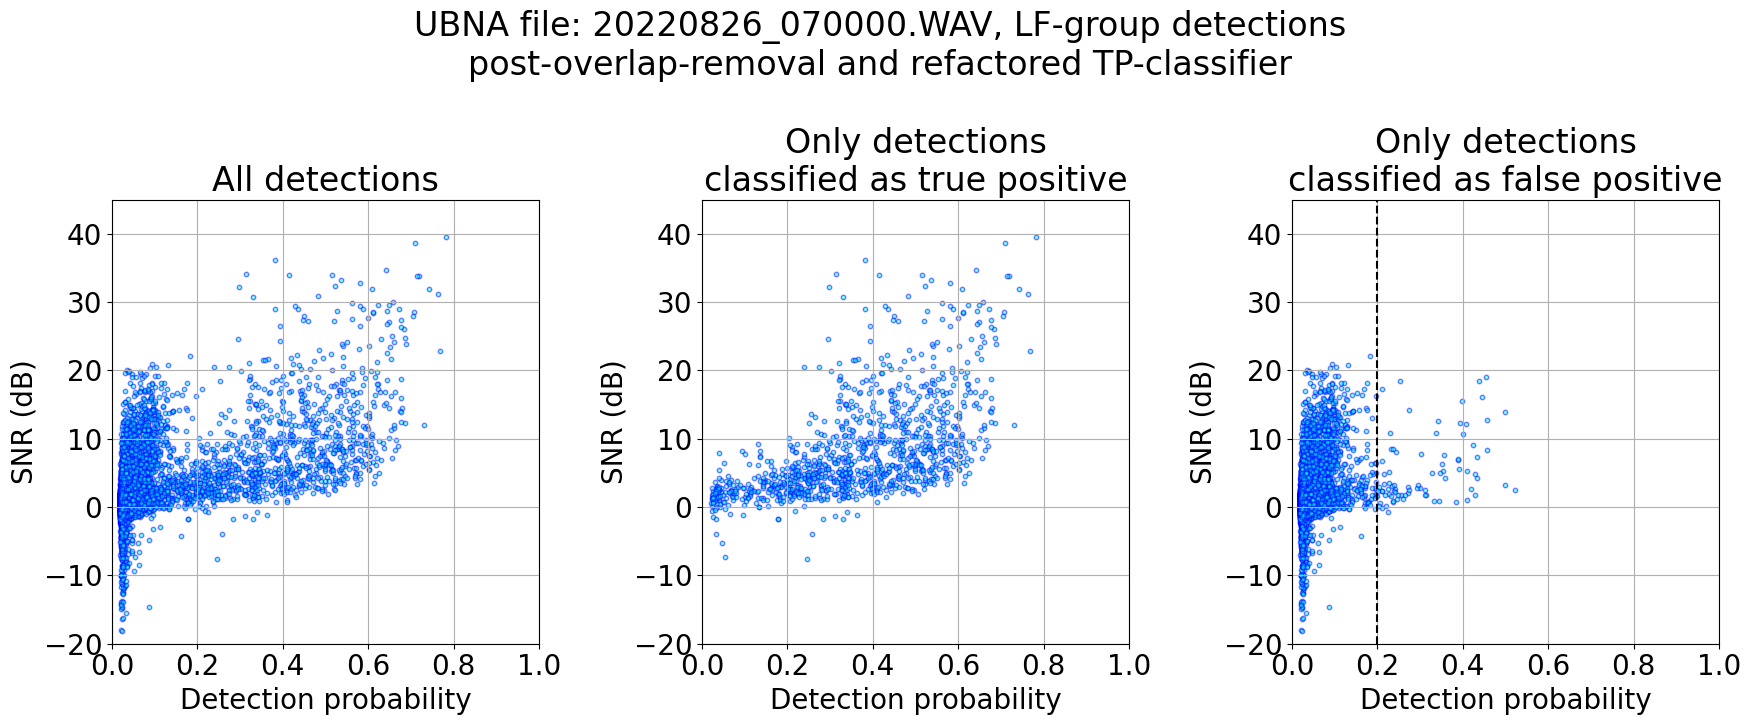

In [37]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18,7.5))
plt.rcParams.update({'font.size':20})

fig.suptitle(f'UBNA file: {wav_filename}.WAV, LF-group detections\npost-overlap-removal and refactored TP-classifier')

ax = ax1
ax.set_title(f'All detections')
ax.scatter(lf_bd2_file_all_dets['det_prob'].values, lf_bd2_file_all_dets['SNR'].values,
            alpha=0.5, s=10, facecolor='cyan', edgecolor='blue')
ax.grid(which='both')
ax.set_xlabel('Detection probability')
ax.set_ylabel('SNR (dB)')
ax.set_xlim(0, 1.0)
ax.set_ylim(-20, 45.0)

ax = ax2
ax.set_title(f'Only detections\nclassified as true positive')
ax.scatter(lf_bd2_true_positives['det_prob'].values, lf_bd2_true_positives['SNR'].values,
            alpha=0.5, s=10, facecolor='cyan', edgecolor='blue')
ax.grid(which='both')
ax.set_xlabel('Detection probability')
ax.set_ylabel('SNR (dB)')
ax.set_xlim(0, 1.0)
ax.set_ylim(-20, 45.0)

ax = ax3
ax.set_title(f'Only detections\nclassified as false positive')
ax.scatter(lf_bd2_false_positives['det_prob'].values, lf_bd2_false_positives['SNR'].values,
            alpha=0.5, s=10, facecolor='cyan', edgecolor='blue')
ax.axvline(x=0.2, linestyle='dashed', color='k')
ax.grid(which='both')
ax.set_xlabel('Detection probability')
ax.set_ylabel('SNR (dB)')
ax.set_xlim(0, 1.0)
ax.set_ylim(-20, 45.0)


fig.tight_layout()
plt.show()

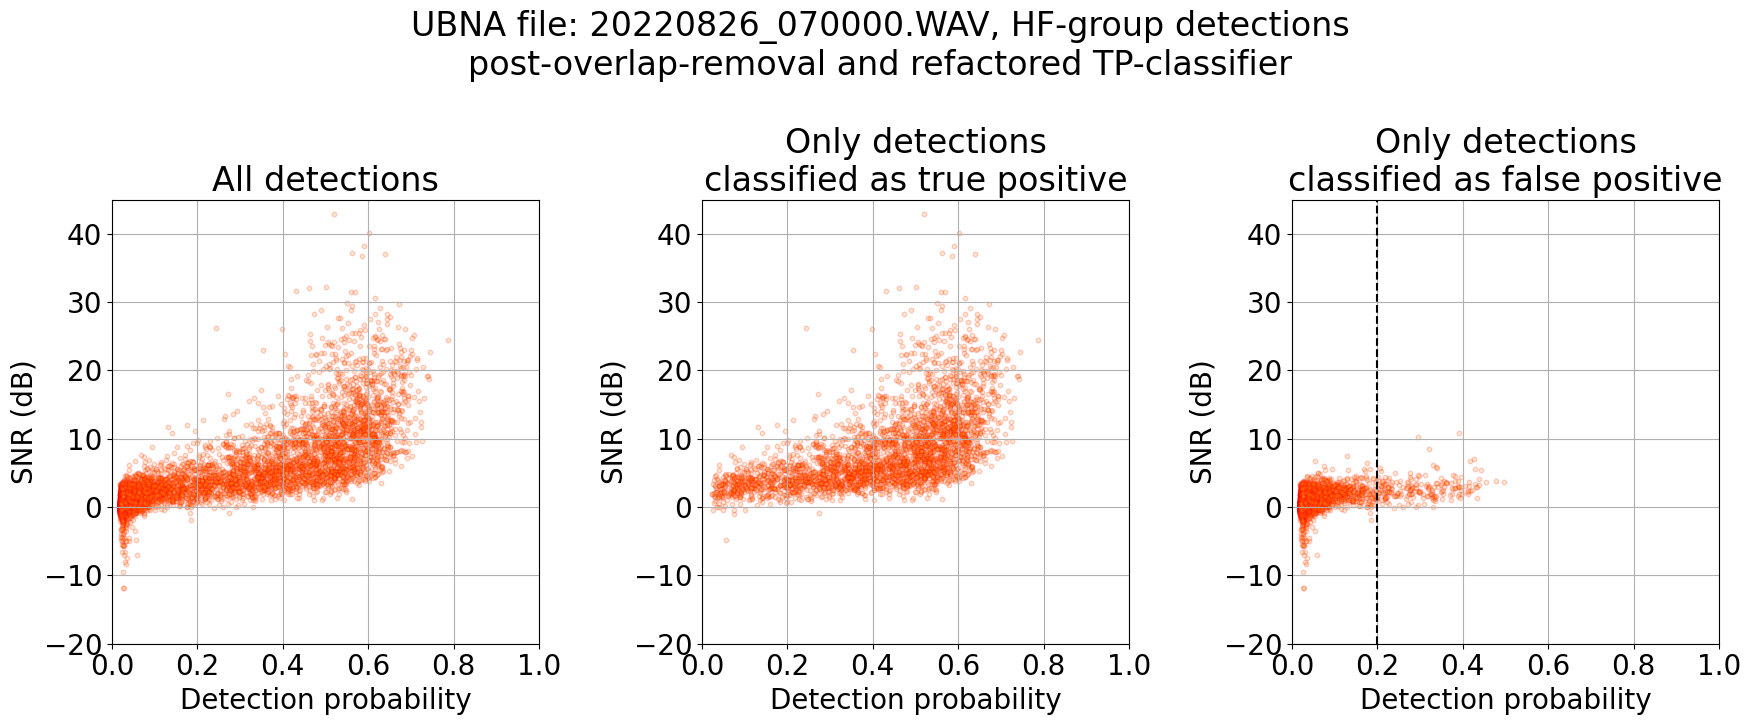

In [38]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18,7.5))
plt.rcParams.update({'font.size':20})

fig.suptitle(f'UBNA file: {wav_filename}.WAV, HF-group detections\npost-overlap-removal and refactored TP-classifier')

ax = ax1
ax.set_title(f'All detections')
ax.scatter(hf_bd2_file_all_dets['det_prob'].values, hf_bd2_file_all_dets['SNR'].values,
            alpha=0.2, s=10, facecolor='orange', edgecolor='red')
ax.grid(which='both')
ax.set_xlabel('Detection probability')
ax.set_ylabel('SNR (dB)')
ax.set_xlim(0, 1.0)
ax.set_ylim(-20, 45.0)

ax = ax2
ax.set_title(f'Only detections\nclassified as true positive')
ax.scatter(hf_bd2_true_positives['det_prob'].values, hf_bd2_true_positives['SNR'].values,
            alpha=0.2, s=10, facecolor='orange', edgecolor='red')
ax.grid(which='both')
ax.set_xlabel('Detection probability')
ax.set_ylabel('SNR (dB)')
ax.set_xlim(0, 1.0)
ax.set_ylim(-20, 45.0)

ax = ax3
ax.set_title(f'Only detections\nclassified as false positive')
ax.scatter(hf_bd2_false_positives['det_prob'].values, hf_bd2_false_positives['SNR'].values,
            alpha=0.2, s=10, facecolor='orange', edgecolor='red')
ax.axvline(x=0.2, linestyle='dashed', color='k')
ax.grid(which='both')
ax.set_xlabel('Detection probability')
ax.set_ylabel('SNR (dB)')
ax.set_xlim(0, 1.0)
ax.set_ylim(-20, 45.0)


fig.tight_layout()
plt.show()

In [39]:
suspect_lf_bd2_false_positives = lf_bd2_false_positives[lf_bd2_false_positives['det_prob']>0.2]
suspect_lf_bd2_false_positives

,freq_group,peak_frequency_time_SPECTROGRAM,peak_frequency_SPECTROGRAM,peak_frequency_WELCH,SNR,start_time,end_time,low_freq,high_freq,class,class_prob,det_prob,individual,event,sampling_rate,input_file
671,LF,38.357567,24000.0,24000.0,5.616124,38.3505,38.3696,22890,28231,Nyctalus leisleri,0.234,0.392,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...
735,LF,42.100500,25500.0,25920.0,2.770194,42.0965,42.1105,23750,28708,Eptesicus serotinus,0.112,0.300,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...
844,LF,47.909100,24000.0,24960.0,3.121589,47.8975,47.9179,23750,27763,Nyctalus leisleri,0.126,0.235,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...
2603,LF,154.512433,26250.0,25920.0,3.234682,154.5045,154.5169,24609,30094,Nyctalus leisleri,0.257,0.500,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...
2701,LF,159.753533,27000.0,26880.0,8.009502,159.7425,159.7623,25468,31392,Nyctalus leisleri,0.113,0.243,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20053,LF,1146.086400,26250.0,26880.0,1.814819,1146.0785,1146.0921,26328,30545,Eptesicus serotinus,0.116,0.248,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...
20761,LF,1186.869833,27000.0,26880.0,0.137072,1186.8645,1186.8760,24609,30118,Eptesicus serotinus,0.080,0.203,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...
20879,LF,1193.254167,26250.0,24960.0,3.586618,1193.2485,1193.2620,25468,29386,Nyctalus leisleri,0.104,0.228,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...
23177,LF,1339.881900,20250.0,20160.0,18.394509,1339.8795,1339.8846,16875,33444,Plecotus austriacus,0.154,0.254,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...


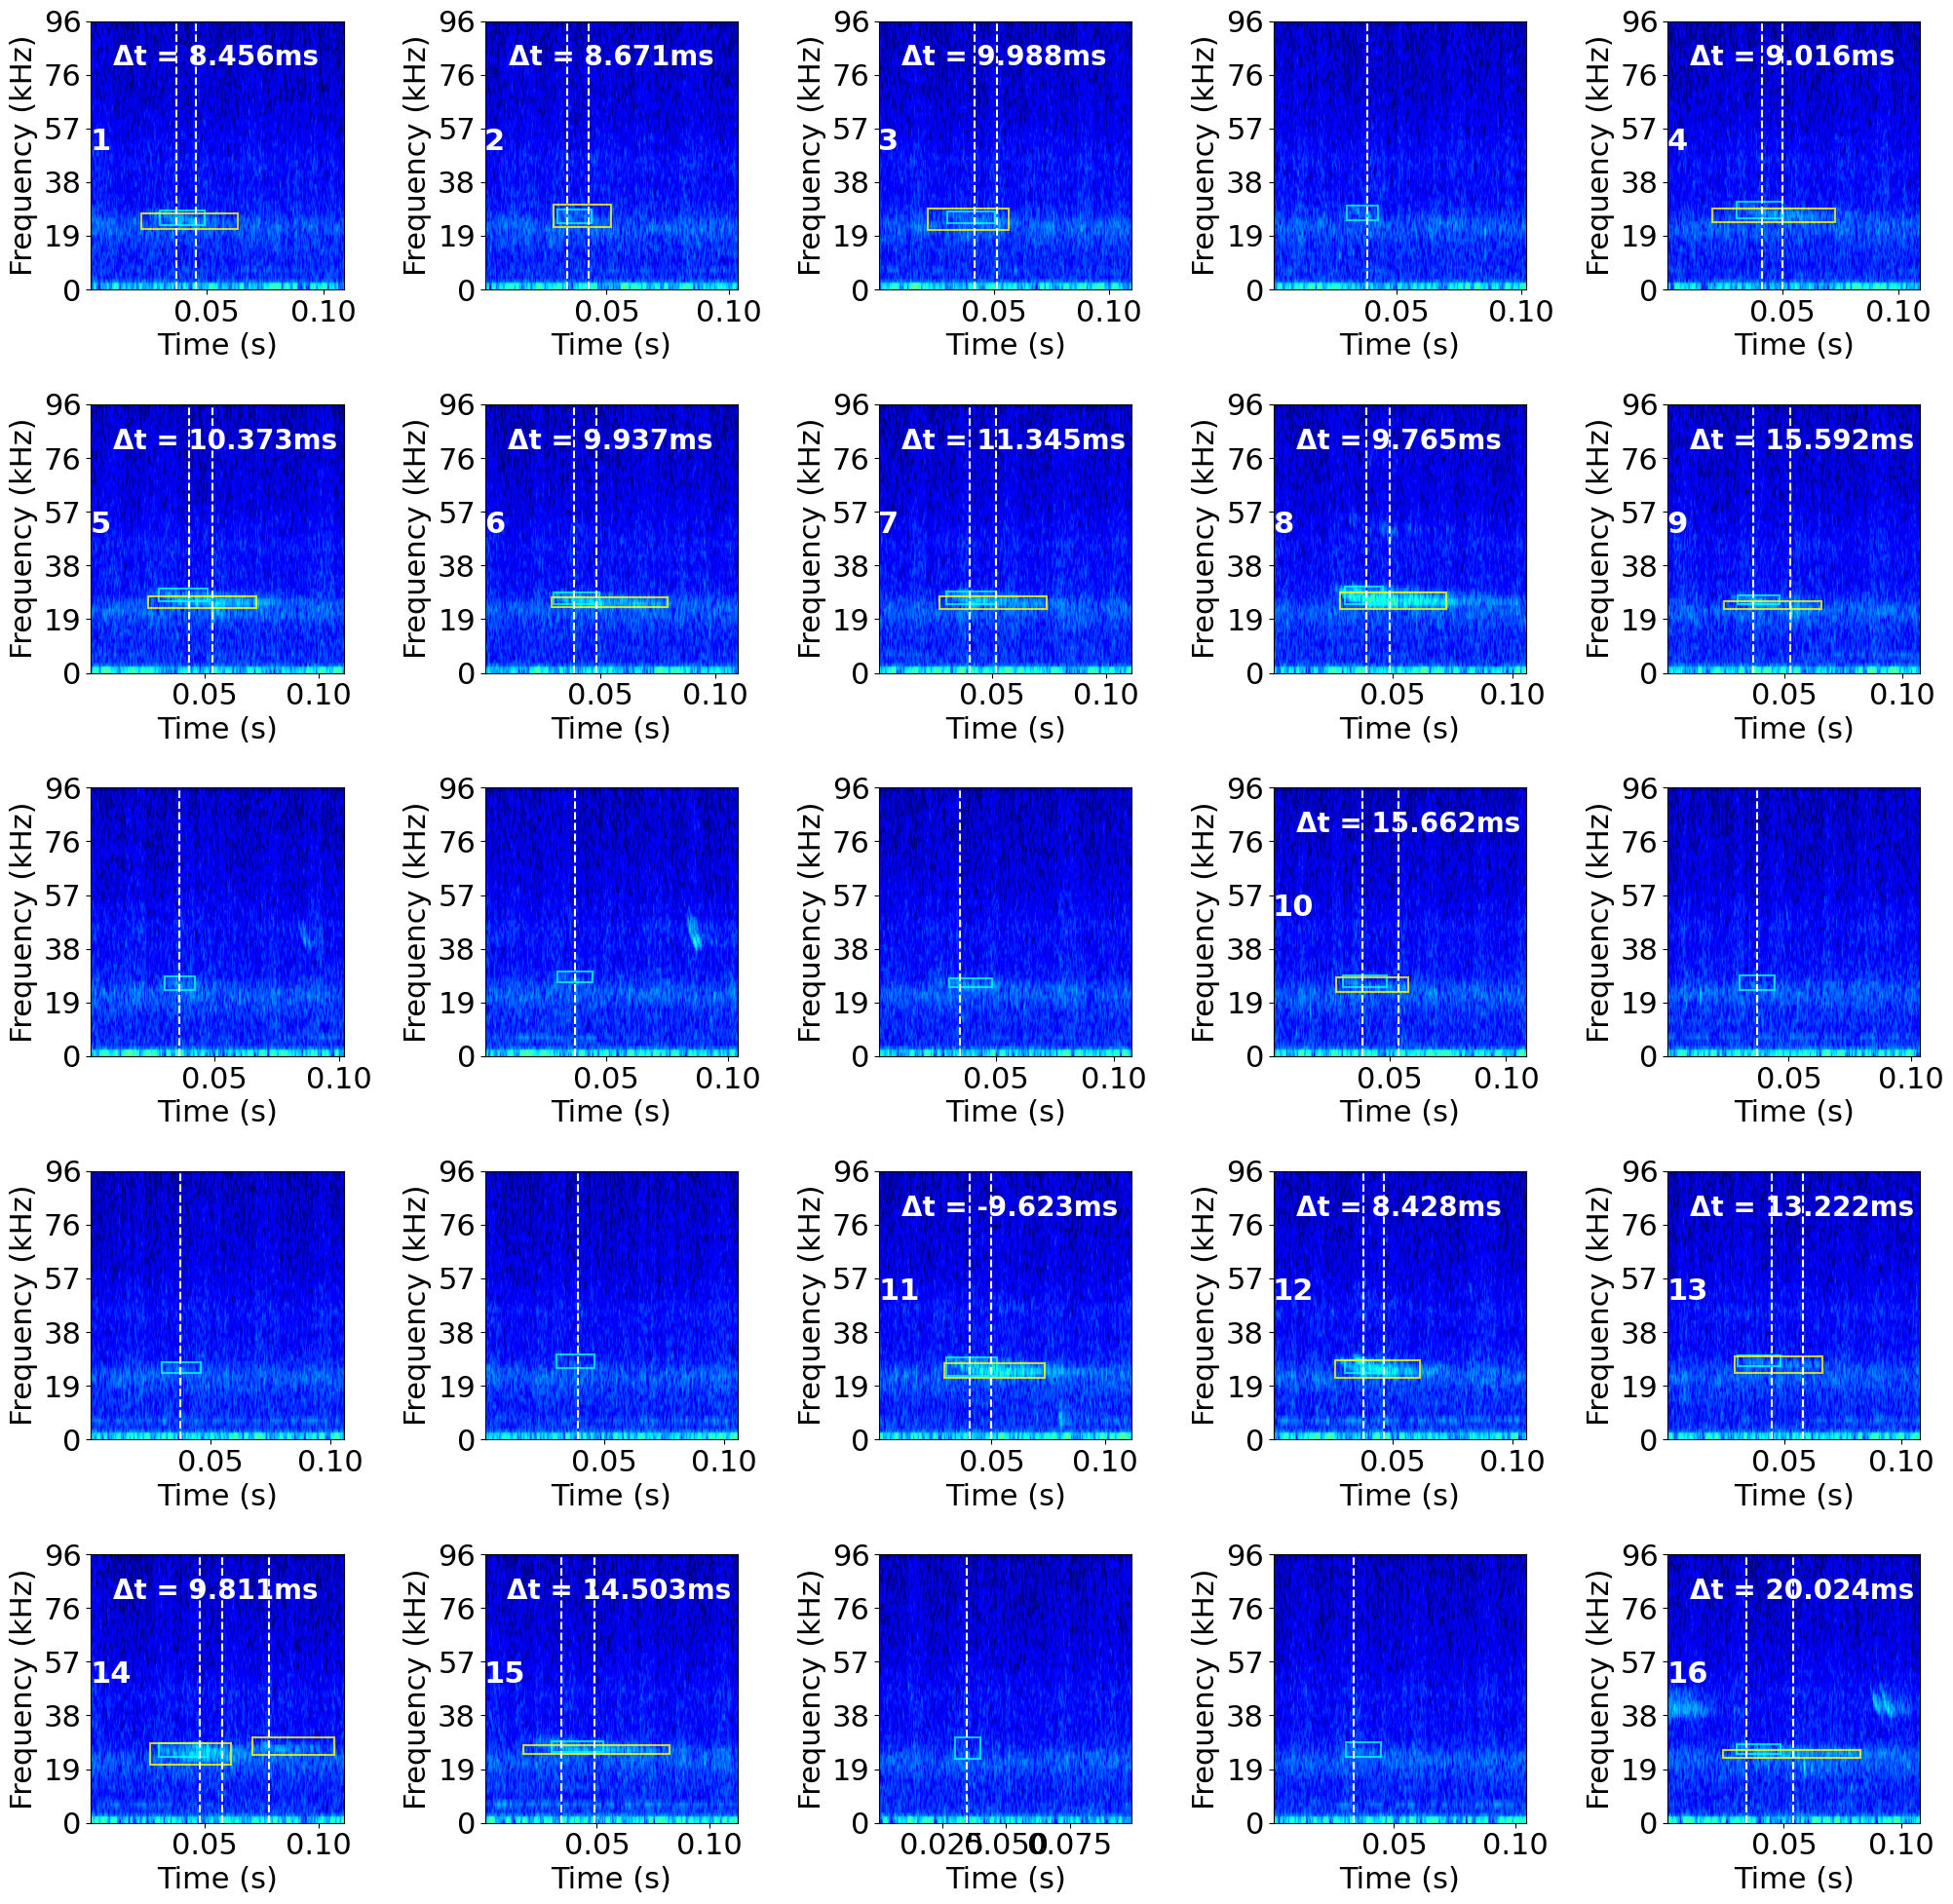

In [40]:
selections = suspect_lf_bd2_false_positives[:25].reset_index(drop=True).copy()
plt.figure(figsize=(4.1*int(np.ceil(len(selections)**0.5)), 4*int(np.ceil(len(selections)**0.5))))
plt.rcParams.update({'font.size': 22})
overlap_count = 0
for ind, selection_row in selections.iterrows():
    plt.subplot(int(np.ceil(len(selections)**0.5)), int(np.ceil(len(selections)**0.5)), ind+1)
    input_file = Path(selection_row['input_file'])
    file_name = input_file.name
    file_path = Path(raventxt_human_files_dir) / file_name
    audio_file = sf.SoundFile(file_path)
    fs = audio_file.samplerate

    raventxt_human_filename = f'{input_file.stem}_manually_verified_by_AK_with_groups'

    start = selection_row['start_time']-0.03
    audio_file.seek(int(fs*(start)))
    duration = (selection_row['end_time']-selection_row['start_time'])+0.09
    audio_seg = audio_file.read(int(fs*duration))

    plt.specgram(audio_seg, NFFT=156, Fs=fs, cmap='jet', vmin=-120, vmax=0)

    ax = plt.gca()
    rect = patches.Rectangle(((selection_row['start_time'] - start), selection_row['low_freq']), 
                    (selection_row['end_time'] - selection_row['start_time']), (selection_row['high_freq'] - selection_row['low_freq']), 
                    linewidth=1.5, edgecolor=FREQ_COLORS[selection_row['freq_group']], facecolor='none', alpha=0.8)
    ax.add_patch(rect)
    ax.axvline(x=selection_row['peak_frequency_time_SPECTROGRAM']-start, linestyle='dashed', color='w')

    plot_humandets = lf_bd2_human_df_file[(lf_bd2_human_df_file['start_time']>=start)&(lf_bd2_human_df_file['end_time']<=(start+duration))]
    for i, row in plot_humandets.iterrows():
        rect = patches.Rectangle(((row['start_time'] - start), row['low_freq']), 
                        (row['end_time'] - row['start_time']), (row['high_freq'] - row['low_freq']), 
                        linewidth=1.5, edgecolor='yellow', facecolor='none', alpha=0.8)
        ax.add_patch(rect)
        ax.axvline(x=row['peak_frequency_time']-start, linestyle='dashed', color='w')
    shortest_t_delay_in_window = np.abs(1000*(plot_humandets['peak_frequency_time'] - selection_row['peak_frequency_time_SPECTROGRAM'])).min()
    shortest_t_distance_in_window = (1000*(plot_humandets['peak_frequency_time'] - selection_row['peak_frequency_time_SPECTROGRAM'])).min()
    if ~(np.isnan(shortest_t_delay_in_window)):
        plt.text(x=0.01, y=80e3, s=f"Δt = {round(shortest_t_distance_in_window, 3)}ms",
                fontsize=20, color='white', fontweight='bold', zorder=2)
    if (np.abs(shortest_t_distance_in_window)<32):
        overlap_count+=1
        plt.text(x=0, y=50e3, s=f'{overlap_count}', color='w', fontweight='bold')
    plt.yticks(ticks=np.linspace(0, fs/2, 6), labels=np.linspace(0, fs/2000, 6).astype('int'))
    plt.ylabel("Frequency (kHz)")
    plt.xlabel("Time (s)")

plt.tight_layout()
plt.show()

In [41]:
selections = suspect_lf_bd2_false_positives.reset_index(drop=True).copy()
overlap_count = 0
overlap_determination_thresh = 32
for ind, selection_row in selections.iterrows():
    raventxt_human_filename = f'{input_file.stem}_manually_verified_by_AK_with_groups'

    start = selection_row['start_time']-0.03
    duration = (selection_row['end_time']-selection_row['start_time'])+0.09
    plot_humandets = lf_bd2_human_df_file[(lf_bd2_human_df_file['start_time']>=start)&(lf_bd2_human_df_file['end_time']<=(start+duration))]
    shortest_t_delay_in_window = np.abs(1000*(plot_humandets['peak_frequency_time'] - selection_row['peak_frequency_time_SPECTROGRAM'])).min()
    shortest_t_distance_in_window = (1000*(plot_humandets['peak_frequency_time'] - selection_row['peak_frequency_time_SPECTROGRAM'])).min()
    if (np.abs(shortest_t_distance_in_window)<overlap_determination_thresh):
        overlap_count+=1
print(f'{overlap_count}/{len(selections)} ({round(overlap_count/len(selections), 3)}) HF false positives were actually true positives with peak times distances > {int(1000*TP_CLASSIFICATION_THRESHOLD)}ms but < {overlap_determination_thresh}ms')

44/81 (0.543) HF false positives were actually true positives with peak times distances > 8ms but < 32ms


In [42]:
suspect_hf_bd2_false_positives = hf_bd2_false_positives[hf_bd2_false_positives['det_prob']>0.2]
suspect_hf_bd2_false_positives

,freq_group,peak_frequency_time_SPECTROGRAM,peak_frequency_SPECTROGRAM,peak_frequency_WELCH,SNR,start_time,end_time,low_freq,high_freq,class,class_prob,det_prob,individual,event,sampling_rate,input_file
408,HF,33.286533,48750.0,48960.0,5.603281,33.2835,33.2903,46953,53159,Pipistrellus pipistrellus,0.403,0.429,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...
415,HF,33.719000,49500.0,48960.0,1.833284,33.7155,33.7230,46093,53579,Pipistrellus pipistrellus,0.204,0.216,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...
471,HF,39.927667,48000.0,48960.0,10.908490,39.9245,39.9300,46953,55476,Pipistrellus pipistrellus,0.302,0.392,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...
477,HF,40.413567,52500.0,49920.0,3.581238,40.4105,40.4161,47812,58828,Pipistrellus pipistrellus,0.345,0.364,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...
502,HF,41.537300,45750.0,48960.0,3.943825,41.5325,41.5387,43515,54026,Pipistrellus pipistrellus,0.147,0.201,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22605,HF,1767.702900,39750.0,39360.0,1.251738,1767.6985,1767.7086,38359,42414,Pipistrellus nathusii,0.293,0.351,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...
22649,HF,1769.614233,41250.0,40320.0,0.081270,1769.6105,1769.6201,39218,43798,Pipistrellus nathusii,0.294,0.331,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...
22714,HF,1774.076933,40500.0,40320.0,1.316114,1774.0725,1774.0814,40078,45892,Pipistrellus nathusii,0.381,0.434,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...
22785,HF,1778.224233,42000.0,43200.0,1.928925,1778.2205,1778.2301,39218,43998,Pipistrellus nathusii,0.220,0.273,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...


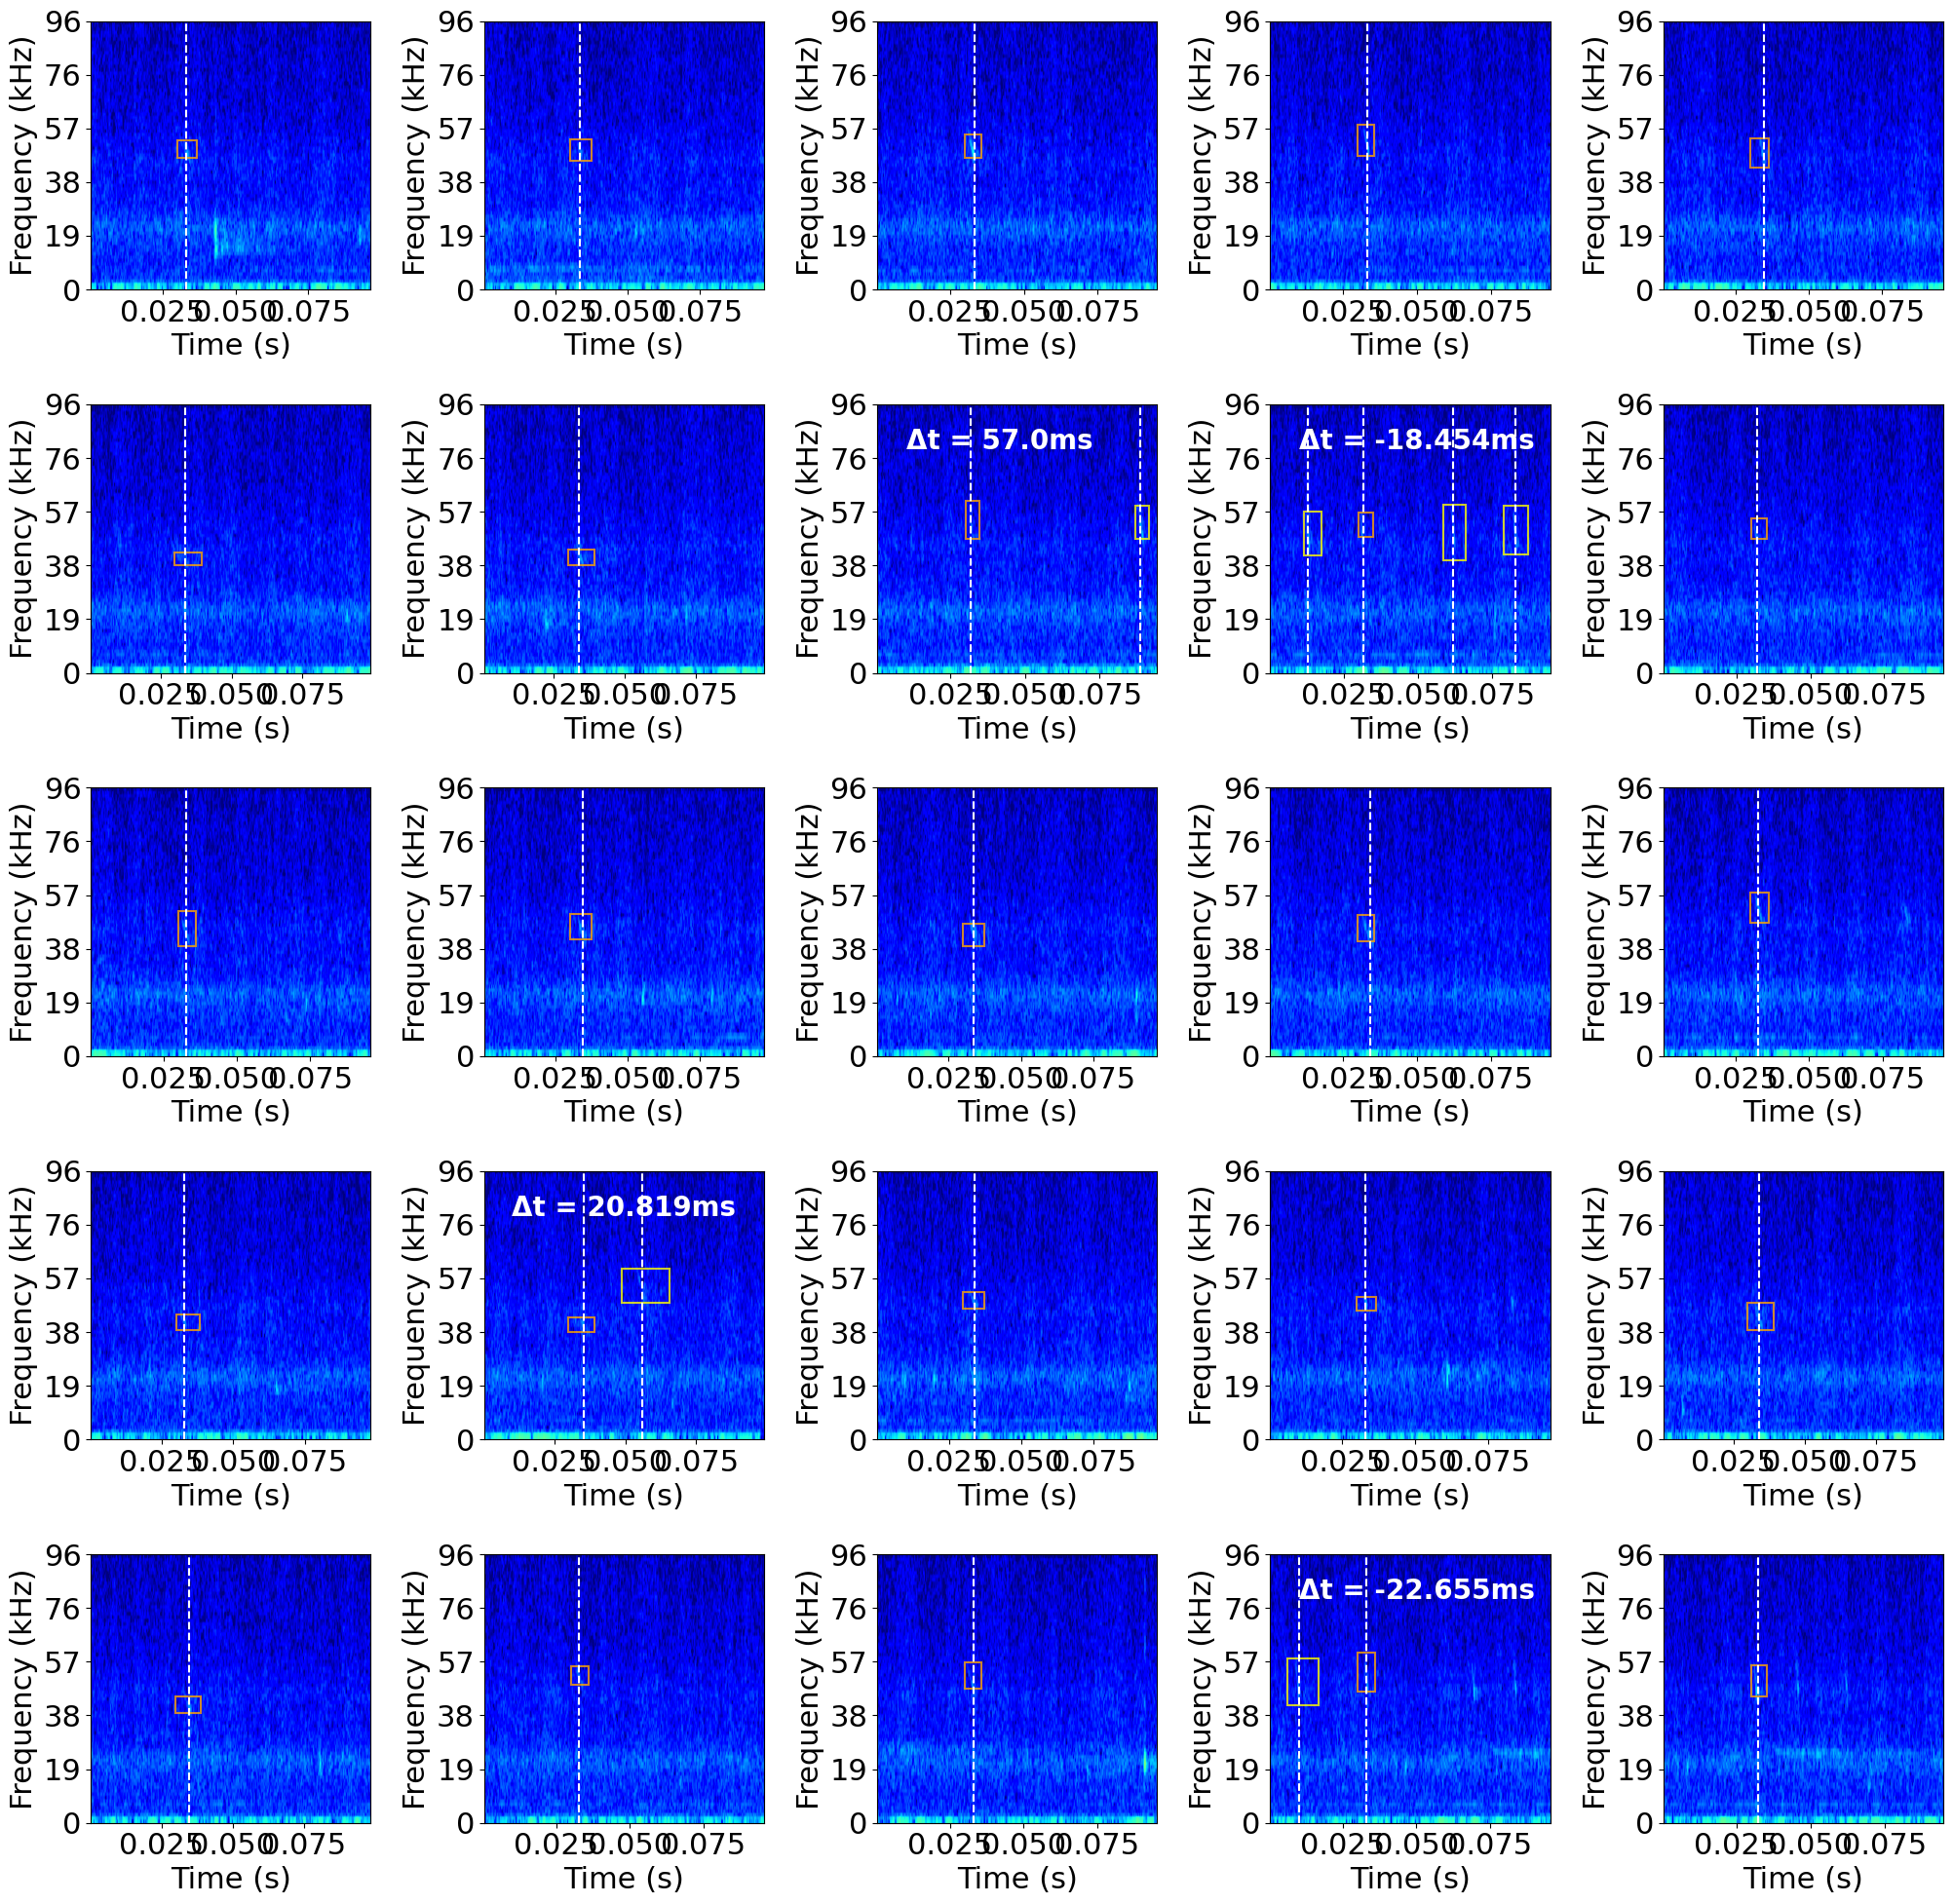

In [43]:
selections = suspect_hf_bd2_false_positives[:25].reset_index(drop=True).copy()
plt.figure(figsize=(4.1*int(np.ceil(len(selections)**0.5)), 4*int(np.ceil(len(selections)**0.5))))
plt.rcParams.update({'font.size': 22})
overlap_count = 0
for ind, selection_row in selections.iterrows():
    plt.subplot(int(np.ceil(len(selections)**0.5)), int(np.ceil(len(selections)**0.5)), ind+1)
    input_file = Path(selection_row['input_file'])
    file_name = input_file.name
    file_path = Path(raventxt_human_files_dir) / file_name
    audio_file = sf.SoundFile(file_path)
    fs = audio_file.samplerate

    file_selections = selections[selections['input_file']==str(input_file)]
    raventxt_human_filename = f'{input_file.stem}_manually_verified_by_AK_with_groups'

    start = selection_row['start_time']-0.03
    audio_file.seek(int(fs*(start)))
    duration = (selection_row['end_time']-selection_row['start_time'])+0.09
    audio_seg = audio_file.read(int(fs*duration))

    plt.specgram(audio_seg, NFFT=156, Fs=fs, cmap='jet', vmin=-120, vmax=0)

    ax = plt.gca()
    rect = patches.Rectangle(((selection_row['start_time'] - start), selection_row['low_freq']), 
                    (selection_row['end_time'] - selection_row['start_time']), (selection_row['high_freq'] - selection_row['low_freq']), 
                    linewidth=1.5, edgecolor=FREQ_COLORS[selection_row['freq_group']], facecolor='none', alpha=0.8)
    ax.add_patch(rect)
    ax.axvline(x=selection_row['peak_frequency_time_SPECTROGRAM']-start, linestyle='dashed', color='w')

    plot_humandets = hf_bd2_human_df_file[(hf_bd2_human_df_file['start_time']>=start)&(hf_bd2_human_df_file['end_time']<=(start+duration))]
    for i, row in plot_humandets.iterrows():
        rect = patches.Rectangle(((row['start_time'] - start), row['low_freq']), 
                        (row['end_time'] - row['start_time']), (row['high_freq'] - row['low_freq']), 
                        linewidth=1.5, edgecolor='yellow', facecolor='none', alpha=0.8)
        ax.add_patch(rect)
        ax.axvline(x=row['peak_frequency_time']-start, linestyle='dashed', color='w')
    shortest_t_delay_in_window = np.abs(1000*(plot_humandets['peak_frequency_time'] - selection_row['peak_frequency_time_SPECTROGRAM'])).min()
    shortest_t_distance_in_window = (1000*(plot_humandets['peak_frequency_time'] - selection_row['peak_frequency_time_SPECTROGRAM'])).min()
    if ~(np.isnan(shortest_t_delay_in_window)):
        plt.text(x=0.01, y=80e3, s=f"Δt = {round(shortest_t_distance_in_window, 3)}ms",
                fontsize=20, color='white', fontweight='bold', zorder=2)
    if (np.abs(shortest_t_distance_in_window)<10):
        overlap_count+=1
        plt.text(x=0, y=50e3, s=f'{overlap_count}', color='w', fontweight='bold')
    plt.yticks(ticks=np.linspace(0, fs/2, 6), labels=np.linspace(0, fs/2000, 6).astype('int'))
    plt.ylabel("Frequency (kHz)")
    plt.xlabel("Time (s)")

plt.tight_layout()
plt.show()

In [44]:
selections = suspect_hf_bd2_false_positives.reset_index(drop=True).copy()
overlap_count = 0
overlap_determination_thresh = 20
for ind, selection_row in selections.iterrows():
    raventxt_human_filename = f'{input_file.stem}_manually_verified_by_AK_with_groups'

    start = selection_row['start_time']-0.03
    duration = (selection_row['end_time']-selection_row['start_time'])+0.09
    plot_humandets = hf_bd2_human_df_file[(hf_bd2_human_df_file['start_time']>=start)&(hf_bd2_human_df_file['end_time']<=(start+duration))]
    shortest_t_delay_in_window = np.abs(1000*(plot_humandets['peak_frequency_time'] - selection_row['peak_frequency_time_SPECTROGRAM'])).min()
    shortest_t_distance_in_window = (1000*(plot_humandets['peak_frequency_time'] - selection_row['peak_frequency_time_SPECTROGRAM'])).min()
    if (np.abs(shortest_t_distance_in_window)<overlap_determination_thresh):
        overlap_count+=1
print(f'{overlap_count}/{len(selections)} ({round(overlap_count/len(selections), 3)}) HF false positives were actually true positives with peak times distances > {int(1000*TP_CLASSIFICATION_THRESHOLD)}ms but < {overlap_determination_thresh}ms')

5/197 (0.025) HF false positives were actually true positives with peak times distances > 8ms but < 20ms
